In [1]:
import sys
import os

# 현재 노트북의 상위 폴더(프로젝트 루트)를 시스템 경로에 추가
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Qubit increse

🚀 Starting Benchmark: Qubits [2, 3, 4, 5, 6]...
   Mode: noiseless, Layers: 3, Optimizer: COBYLA
------------------------------------------------------------
[Qubits=2] Setting up... Running VQE... [INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...
[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Done! (Time: 1.88s, Cost: -0.0148, Fidelity: 0.9937)))

[Qubits=3] Setting up... Running VQE... [INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...
[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Done! (Time: 4.11s, Cost: 0.0533, Fidelity: 0.9615)1)

[Qubits=4] Setting up... Running VQE... [INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...
[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Done! (Time: 10.85s, Cost: 0.2200, Fidelity: 0.7797))

[Qubits=5] Setting up... Running VQE... [IN

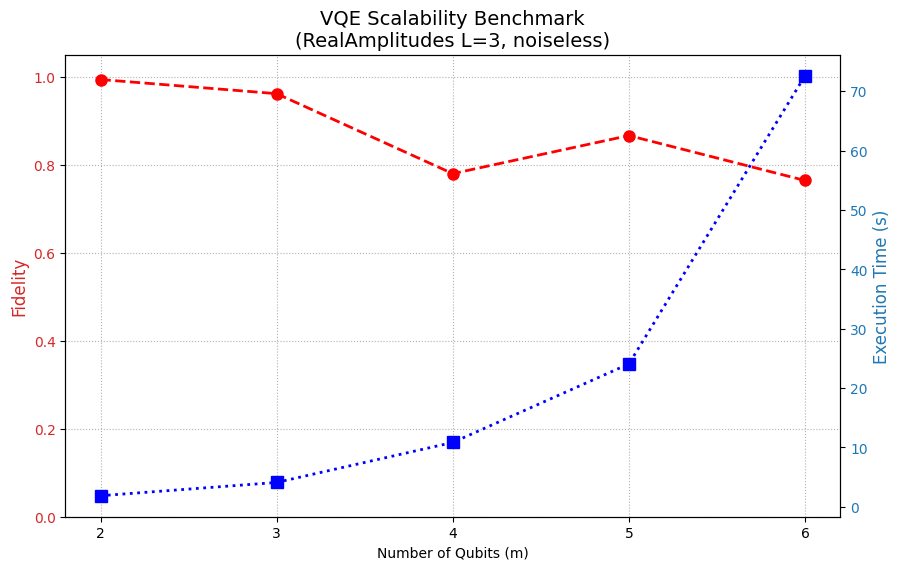

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, StatePreparation
from qiskit.quantum_info import Statevector
from src.ansatz import create_qaoa_ansatz

# --- [설정] 벤치마크 파라미터 ---
qubit_range = range(2, 7)  # 2, 3, 4, 5, 6 큐비트
layers = 3                 # Ansatz 레이어 수
backend_mode = 'noiseless' # 'noiseless' (추천) or 'noisy_sim'
optimizer = 'COBYLA'
options = {'maxiter': 2500, 'tol': 1e-4}

# 결과 저장용 리스트
fidelities = []
times = []
costs = []

print(f"🚀 Starting Benchmark: Qubits {list(qubit_range)}...")
print(f"   Mode: {backend_mode}, Layers: {layers}, Optimizer: {optimizer}")
print("-" * 60)

for m in qubit_range:
    start_time = time.time()
    print(f"[Qubits={m}] Setting up...", end=" ")
    
    # 1. 문제 정의 (Gaussian b)
    from src.problem_setup import get_b_statevector, create_b_vector_gaussian
    b_vec, b_data = get_b_statevector(m, create_b_vector_gaussian)
    
    # 2. Ansatz 및 회로 준비
    ansatz = create_qaoa_ansatz(m, layers=layers)
    
    b_circuit = QuantumCircuit(m)
    b_circuit.append(StatePreparation(b_data), range(m))
    
    # 3. VQE 실행 (Hardware Solver)
    from src.solvers.hardware import run_vqe_fully_hardware_v2
    
    print("Running VQE...", end=" ")
    result = run_vqe_fully_hardware_v2(
        m, ansatz, b_circuit, 
        backend_mode=backend_mode,
        optimizer=optimizer,
        options=options
    )
    
    # 4. 결과 분석
    elapsed = time.time() - start_time
    times.append(elapsed)
    costs.append(result.fun)
    
    # Fidelity 계산
    opt_params = result.x
    final_state = Statevector(ansatz.assign_parameters(opt_params))
    
    # 고전적 정답 (이전에 정의한 함수 사용)
    # (노트북 내에 get_classical_solution 함수가 정의되어 있어야 함. 없다면 아래 주석 해제하여 사용)
    # exact_sol = get_classical_poisson_solution(m, b_data.real) 
    
    # 만약 get_classical_solution이 없다면 간단히 여기서 계산:
    from scipy.sparse import diags
    import scipy.linalg as la
    N = 2**m
    diagonals = [2*np.ones(N), -1*np.ones(N-1), -1*np.ones(N-1)]
    A_mat = diags(diagonals, [0, 1, -1]).toarray()
    try: x_ex = la.solve(A_mat, b_data.real)
    except: x_ex = la.pinv(A_mat) @ b_data.real
    exact_sol = x_ex / np.linalg.norm(x_ex)

    fid = np.abs(np.dot(final_state.data.conj(), exact_sol))**2
    fidelities.append(fid)
    
    print(f"Done! (Time: {elapsed:.2f}s, Cost: {result.fun:.4f}, Fidelity: {fid:.4f})\n")

print("-" * 60)
print("Benchmark Complete.")

# --- 그래프 그리기 ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Fidelity (왼쪽 축)
color = 'tab:red'
ax1.set_xlabel('Number of Qubits (m)')
ax1.set_ylabel('Fidelity', color=color, fontsize=12)
ax1.plot(qubit_range, fidelities, 'ro--', markersize=8, linewidth=2, label='Fidelity')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.05)
ax1.grid(True, linestyle=':')

# 실행 시간 (오른쪽 축)
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Execution Time (s)', color=color, fontsize=12)  
ax2.plot(qubit_range, times, 'bs:', markersize=8, linewidth=2, label='Time (s)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"VQE Scalability Benchmark\n(RealAmplitudes L={layers}, {backend_mode})", fontsize=14)
plt.xticks(qubit_range)
plt.show()


🚀 Starting Layer Benchmark: Fixed 4 Qubits
   Layers p=[1, 2, 3, 4], Mode=noiseless
------------------------------------------------------------
[Layer p=1] Running (Params=2)... [INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...
[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Done! (T=4.28s, Fid=0.8212)2>=0.1665, Overlap=0.0020)

[Layer p=2] Running (Params=4)... [INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...
[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Done! (T=5.86s, Fid=0.8538)2>=0.1167, Overlap=0.0017)

[Layer p=3] Running (Params=6)... [INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...
[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Done! (T=9.67s, Fid=0.8516)2>=0.1252, Overlap=0.0010)

[Layer p=4] Running (Params=8)... [INFO] Setting up backend for mode: nois

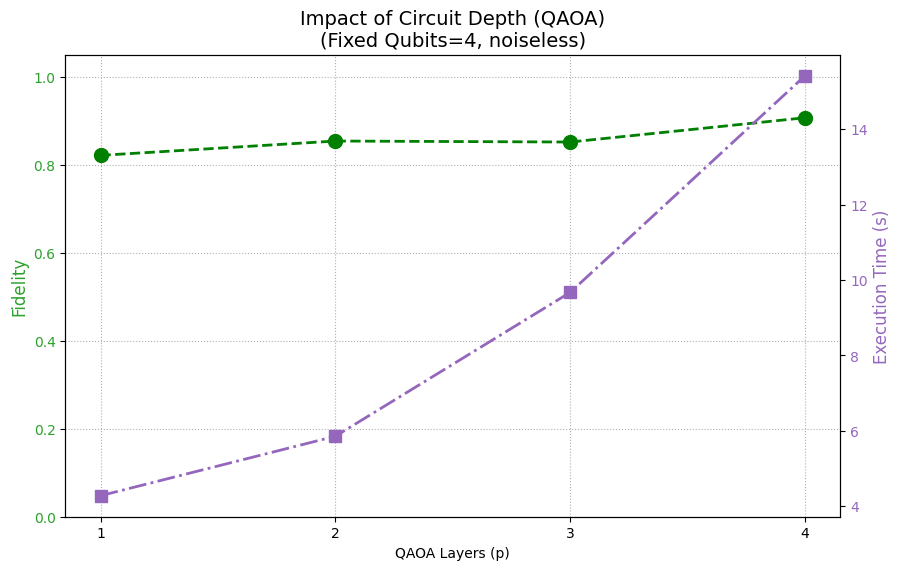

In [6]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector

# ====================================================
# [1] 경로 설정 (필요시)
# ====================================================
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# 라이브러리 임포트
from src.ansatz import create_qaoa_ansatz
from src.problem_setup import get_b_statevector, create_b_vector_gaussian
from src.solvers.hardware import run_vqe_fully_hardware_v2

# ====================================================
# [2] 벤치마크 설정
# ====================================================
m_qubits = 4               # 큐비트 수 고정 (4큐비트 권장)
layer_range = range(1, 5)  # 레이어 p = 1, 2, 3, 4
backend_mode = 'noiseless' # 'noiseless' 추천
optimizer = 'COBYLA'
options = {'maxiter': 2500, 'tol': 1e-5}

fidelities = []
times = []

print(f"\n🚀 Starting Layer Benchmark: Fixed {m_qubits} Qubits")
print(f"   Layers p={list(layer_range)}, Mode={backend_mode}")
print("-" * 60)

# ====================================================
# [3] 루프 실행 (레이어 변화)
# ====================================================
for p in layer_range:
    start_time = time.time()
    print(f"[Layer p={p}]", end=" ")
    
    # 1. 문제 정의 (Gaussian b)
    b_vec, b_data = get_b_statevector(m_qubits, create_b_vector_gaussian)
    
    # 2. Ansatz 생성 (QAOA 레이어 p 적용)
    ansatz = create_qaoa_ansatz(m_qubits, layers=p)
    
    # 3. 회로 준비
    b_circuit = QuantumCircuit(m_qubits)
    b_circuit.append(StatePreparation(b_data), range(m_qubits))
    
    # 4. VQE 실행
    print(f"Running (Params={ansatz.num_parameters})...", end=" ")
    result = run_vqe_fully_hardware_v2(
        m_qubits, ansatz, b_circuit, 
        backend_mode=backend_mode,
        optimizer=optimizer,
        options=options
    )
    
    # 5. 결과 분석
    elapsed = time.time() - start_time
    times.append(elapsed)
    
    # Fidelity 계산
    opt_params = result.x
    final_state = Statevector(ansatz.assign_parameters(opt_params))
    
    # 고전적 정답 계산
    from scipy.sparse import diags
    import scipy.linalg as la
    N = 2**m_qubits
    diagonals = [2*np.ones(N), -1*np.ones(N-1), -1*np.ones(N-1)]
    A_mat = diags(diagonals, [0, 1, -1]).toarray()
    try: x_ex = la.solve(A_mat, b_data.real)
    except: x_ex = la.pinv(A_mat) @ b_data.real
    exact_sol = x_ex / np.linalg.norm(x_ex)

    fid = np.abs(np.dot(final_state.data.conj(), exact_sol))**2
    fidelities.append(fid)
    
    print(f"Done! (T={elapsed:.2f}s, Fid={fid:.4f})\n")

print("-" * 60)
print("Benchmark Complete.")

# ====================================================
# [4] 그래프 시각화
# ====================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Fidelity (왼쪽 축)
color = 'tab:green'
ax1.set_xlabel('QAOA Layers (p)')
ax1.set_ylabel('Fidelity', color=color, fontsize=12)
ax1.plot(layer_range, fidelities, 'go--', markersize=10, linewidth=2, label='Fidelity')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.05)
ax1.set_xticks(layer_range)
ax1.grid(True, linestyle=':')

# 실행 시간 (오른쪽 축)
ax2 = ax1.twinx()  
color = 'tab:purple'
ax2.set_ylabel('Execution Time (s)', color=color, fontsize=12)  
ax2.plot(layer_range, times, 's-.', color=color, markersize=8, linewidth=2, label='Time (s)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"Impact of Circuit Depth (QAOA)\n(Fixed Qubits={m_qubits}, {backend_mode})", fontsize=14)
plt.show()